# US Accidents Risk Prediction (Unbiased & High Accuracy)

## 1. Data Acquisition & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load Dataset
file_path = 'smart_traffic_accident_risk_dataset_2023.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File {file_path} not found.")

Dataset loaded successfully.
Shape: (50000, 30)


## 2. Preprocessing: Unbiased Risk Score
To avoid bias and data leakage, we define the Risk Score primarily based on **Environmental Factors** (Weather, Road, Turn, Speed). We reduce the weight of Severity so the model learns to predict risks from conditions, not outcomes.

In [3]:
# 1. Mappings
severity_map = {'Minor': 1, 'Serious': 3, 'Fatal': 5}
df['Severity_Score'] = df['Injury_Severity'].map(severity_map).fillna(1)

def get_weather_score(w):
    w = str(w).lower()
    if 'rain' in w or 'storm' in w or 'snow' in w: return 1.0
    if 'fog' in w or 'mist' in w: return 0.8
    if 'cloud' in w: return 0.4
    return 0.1
df['Weather_Score'] = df['Weather_Condition'].apply(get_weather_score)

def get_road_score(r):
    r = str(r).lower()
    if 'wet' in r or 'ice' in r or 'oil' in r: return 1.0
    if 'uneven' in r: return 0.7
    return 0.1
df['Road_Score'] = df['Road_Surface'].apply(get_road_score)

def get_light_score(l):
    l = str(l).lower()
    if 'dark' in l or 'night' in l: return 1.0
    if 'dusk' in l or 'dawn' in l: return 0.7
    return 0.1
df['Light_Score'] = df['Lighting_Condition'].apply(get_light_score)

def get_traffic_score(t):
    t = str(t).lower()
    if 'high' in t or 'heavy' in t: return 1.0
    if 'medium' in t: return 0.5
    return 0.1
df['Traffic_Score'] = df['Traffic_Density'].apply(get_traffic_score)

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# 2. Calculate Score (Unbiased Formula)
# Weights: Env(4) + Traf(3) > Sev(1)
w_sev = 1.0
w_env = 4.0
w_traf = 3.0
w_phys = 2.0

df['Calculated_Risk_Score'] = (
    df['Severity_Score'] * w_sev + 
    (df['Weather_Score'] + df['Road_Score'] + df['Light_Score']) * w_env + 
    df['Traffic_Score'] * w_traf + 
    (normalize(df['Speed_Limit']) + normalize(df['Rainfall_mm']) + normalize(df['WindSpeed_kmh'])) * w_phys
)

# 3. Quantize
df['Risk_Label'] = pd.qcut(df['Calculated_Risk_Score'], q=3, labels=['Low', 'Medium', 'High'])
print("Risk Label Distribution:\n", df['Risk_Label'].value_counts())

# 4. Missing Values
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    if col != 'Risk_Label':
        df[col].fillna(df[col].mode()[0], inplace=True)


Risk Label Distribution:
 Risk_Label
Low       16667
High      16667
Medium    16666
Name: count, dtype: int64


## 3. Modeling (XGBoost)

Training XGBoost...


C:\Users\THISLAPTOP\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:199: UserWarning: [00:57:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8765

Classification Report:
               precision    recall  f1-score   support

        High       0.96      0.82      0.88      3334
         Low       0.87      0.96      0.92      3333
      Medium       0.81      0.84      0.83      3333

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



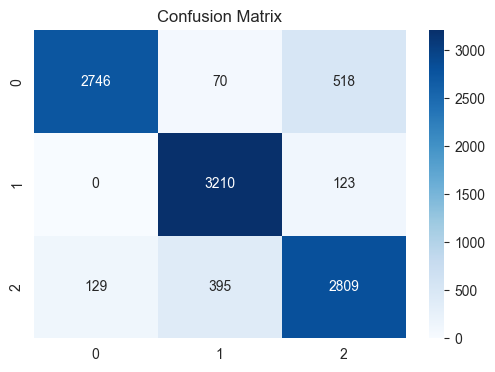

In [4]:
# Prepare Data: Remove Severity from Inputs!
drop_cols = [
    'Accident_Risk', 'Accident_Risk_Score', 'Date', 'Start_Time', 
    'Risk_Label', 'Calculated_Risk_Score', 
    'Severity_Score', 'Injury_Severity', # Bias removed
    'Weather_Score', 'Road_Score', 'Light_Score', 'Traffic_Score'
]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['Risk_Label']

# Encode
encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Train
print("Training XGBoost...")
clf = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False
)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_target.classes_))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Model Comparison: XGBoost vs Random Forest vs Other Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

print("=" * 80)
print("MODEL COMPARISON: XGBoost vs Other ML Models")
print("=" * 80)

# Dictionary to store models and results
models = {
    'XGBoost': clf,  # Already trained
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate all models
results = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    if model_name != 'XGBoost':  # XGBoost already trained
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred_model = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred_model)
    precision = precision_score(y_test, y_pred_model, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_model, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_model, average='weighted', zero_division=0)
    
    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"✓ {model_name}: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "=" * 80)
print("OVERALL COMPARISON TABLE")
print("=" * 80)
print(results_df.to_string(index=False))

# Visualization: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ML Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors[:len(results_df)])
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
                ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary Statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"Best Model (Accuracy): {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Accuracy']:.4f})")
print(f"Best Model (F1-Score): {results_df.loc[results_df['F1-Score'].idxmax()]['Model']} ({results_df['F1-Score'].max():.4f})")
print(f"Average Accuracy: {results_df['Accuracy'].mean():.4f}")
print(f"Std Dev Accuracy: {results_df['Accuracy'].std():.4f}")
